# Try to use pytorch on the PPMI data

First import libs and define paths

In [2]:
import pandas as pd
import os

In [3]:

base_path = "/home/data/PPMI"
participants_file = os.path.join(base_path, "rawdata/participants.tsv")
curated_file = os.path.join(base_path, "documents/PPMI_Curated_Data_Cut_Public_20240729.xlsx")

In [4]:
# ----------------------- mirar tsv
print("Info on participants.tsv")
try:
    df_p = pd.read_csv(participants_file, sep='\t')
    print("Total subjects: ", len(df_p))

    # Look for a 'diagnosis' or 'group' column
    if 'diagnosis' in df_p.columns:
        print(df_p['diagnosis'].value_counts())
    else:
        print("Columns available:", df_p.columns.tolist())
except Exception as e:
    print("Could not read participants.tsv: ", e)

Info on participants.tsv
Total subjects:  955
Columns available: ['participant_id', 'cohort', 'sex', 'birth_date', 'education', 'handed']


In [5]:
# ----------------------- mirar excel
print("Info on the excel")
try:
    df_c = pd.read_excel(curated_file)
    print(f"Total entries in curated data: {len(df_c)}")

    # Common PPMI diagnosis labels: PD (Parkinson's), HC (Healthy Control), SWEDD
    if 'COHORT_DEFINITION' in df_c.columns:
        print(df_c['COHORT_DEFINITION'].value_counts())
    else:
        # If the column name is different lemme see them
        print("Columns available:", df_c.columns.tolist()[:10], "...(truncated)")

except Exception as e:
    print(f"Could not read Excel file: {e}")

Info on the excel
Total entries in curated data: 13242
Columns available: ['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG'] ...(truncated)


# Pytorch

If all above works, load `pytorch` and `nibabel`.

In [6]:
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np

pytorch needs a dataset class to handle the "fetching" of stuff like which patient is and is not sick.

In [7]:
class PPMIDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load the 3D NIfTI file
        img = nib.load(self.file_paths[idx]).get_fdata()

        # Preprocessing
        img = (img - np.mean(img)) / np.std(img) # Normalize intensity

        # Convert to Torch Tensor (Add a 'channel' dimension for the CNN)
        # Shape becomes: [1, Depth, Height, Width]
        img_tensor = torch.from_numpy(img).float().unsqueeze(0)

        label = torch.tensor(self.labels[idx])
        return img_tensor, label

In [8]:
import glob

In [9]:
derivatives_path = os.path.join(base_path, "derivatives/dat-reg-v6")
excel_path = os.path.join(base_path, "documents/PPMI_Curated_Data_Cut_Public_20240729.xlsx")

# Load the labels
df = pd.read_excel(excel_path)

# agafam només el num del pacient i el seu cohort
labels_map = df[['PATNO', 'COHORT']].drop_duplicates().set_index('PATNO')['COHORT'].to_dict()
#print("labels map: ", labels_map)

# trobam totes les "ses-BL" de DaTscan
baseline_images = glob.glob(f"{derivatives_path}/sub-*/ses-BL/spect/*_DaTSCAN.nii.gz") # màgia negra
#print("baseline_images: ", baseline_images)

data_list = []

for img_path in baseline_images:

    # agafam PATNO com a int del filename (aka sub-PPMI100001 -> 100001)
    sub_id = img_path.split('/')[-4] # només 'sub-PPMI100001'
    patno = int(sub_id.replace('sub-PPMI', ''))

    # haurien d ser iguals
    #print("img_path:\t", img_path)
    #print("patno:\t", patno)

    # agafam el cohort si el pacient tenia metadades al excel
    # segur q pandas té algo més ràpid x fer això
    if patno in labels_map:
        cohort = labels_map[patno]
        # x ara només interessen els PD i healthy
        if cohort in [1, 2]: #  cohort 1 són els PD i cohort 2 són els healthy
            label = 1 if cohort == 1 else 0 # els PD es marquen com 1 i els healthy es posen a 0
            #data_list.append({'path': img_path, 'label': label, 'cohort': cohort})
            data_list.append({'path': img_path, 'label': label})

# Create a final clean CSV for training
clean_df = pd.DataFrame(data_list)
print("clean_df:")
print(clean_df.head(10))
print(clean_df['label'].value_counts())

clean_df:
                                                path  label
0  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
1  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
2  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
3  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      0
4  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
5  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
6  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
7  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
8  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
9  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      0
label
1    561
0    124
Name: count, dtype: int64


In [10]:
# save the mapping to a file
clean_df.to_csv("ppmi_baseline_mapping.csv", index=False)
print("\nMapping saved to 'ppmi_baseline_mapping.csv'!")


Mapping saved to 'ppmi_baseline_mapping.csv'!


Now we have a cleaned-up dataset with only PD or not.

# Train-test split

Now scikit learn comes in to train-split the dataset

In [11]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("ppmi_baseline_mapping.csv")
# 80% Train, 20% Test/Validation for now?


# Separate the classes
pd_df = df[df['label'] == 1]
hc_df = df[df['label'] == 0]

pd_df_balanced = pd_df.sample(n=int(1.5*len(hc_df)), random_state=42)
balanced_df = pd.concat([pd_df_balanced, hc_df])
# new split
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=42)

#train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=69)

print(f"Original df: {len(balanced_df)} samples")
print(f"Training on: {len(train_df)} samples")
print(f"Testing on: {len(test_df)} samples")

Original df: 310 samples
Training on: 248 samples
Testing on: 62 samples


# CNN

And once that's done, onto creating the CNN


## Arreglar `pytorch`/cuda:

Per algun motiu, cada pic em demana que em reinstali cuda amb la versió 12.6 tot i haver-ho fet. Desinstalar i reinstalar ho soluciona. Tarda ~1 min.
```sh
pip3 uninstall torch torchvision
pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```

In [12]:
import torch
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"Compute Capability: {torch.cuda.get_device_capability(0)}")
print(f"PyTorch CUDA version: {torch.version.cuda}")

GPU Name: NVIDIA GeForce GTX 1080 Ti
Compute Capability: (6, 1)
PyTorch CUDA version: 12.4


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ParkinsonClassifier3D_v1(nn.Module):
    def __init__(self):
        super(ParkinsonClassifier3D_v1, self).__init__()
        # Input: 1 channel (scan), Output: 16 filters
        self.conv1 = nn.Conv3d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool3d(2)

        self.conv2 = nn.Conv3d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv3d(32, 64, kernel_size=3, padding=1)

        # This part depends on image dimensions (91x109x91, isnt it?)
        # Global Average Pooling to avoid calculating flat dimensions
        self.gap = nn.AdaptiveAvgPool3d(1)

        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1) # Binary output (0 or 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.gap(x) # Flattens to [Batch, 64, 1, 1, 1]
        x = x.view(-1, 64) # Flattens to [Batch, 64]

        x = F.relu(self.fc1(x))
        # sigmoid for binary classification probability bcs why not
        x = torch.sigmoid(self.fc2(x))
        return x

model = ParkinsonClassifier3D_v1().to("cuda") # Send to GPU

## Loading the images

Nibabel is handy here since it takes the .nii.gz files and loads them to images.

In [14]:
import nibabel as nib
from torch.utils.data import Dataset, DataLoader

This is just a quik test to see if nibabel is properly set and if the images are being loaded adequately.

I don't really need nibabel anymore now but I've kept this part since it allows me to visualise the images just like they've are originally.

Input unprocessed images (slice 48)


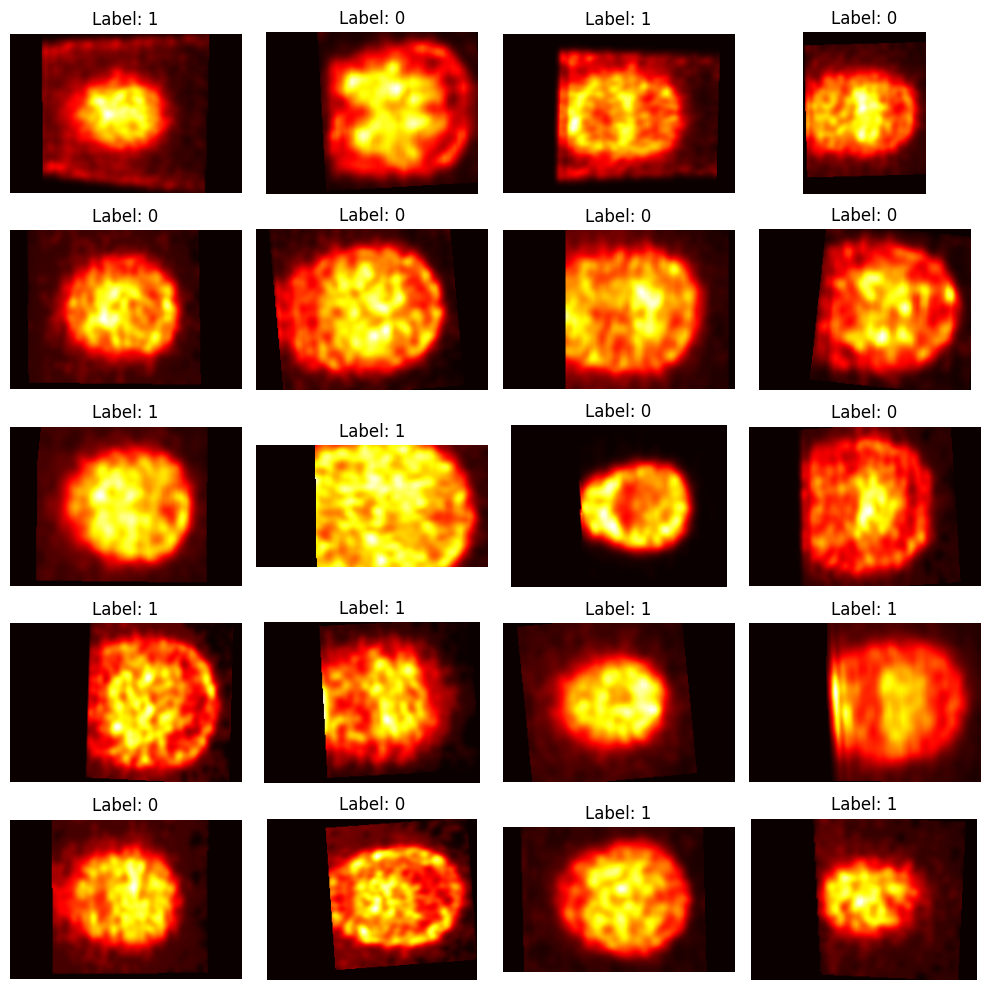

In [15]:
######################### testing nibabel

import matplotlib.pyplot as plt

w = 10
h = 10
fig = plt.figure(figsize=(10, 10))
columns = 4
rows = 5
for i in range(1, columns*rows +1):

    ist_path = train_df.iloc[i]['path']
    ist_label = train_df.iloc[i]['label']

    ist_img = nib.load(ist_path)
    ist_img_data = ist_img.get_fdata()

    test = ist_img_data[:,48,:] 

    fig.add_subplot(rows, columns, i)
    plt.imshow(test, cmap="hot")
    plt.title(f"Label: {ist_label}")
    plt.axis("off")

print("Input unprocessed images (slice 48)")
plt.tight_layout()
plt.show()



Imatges tal qual (pre-monai)
La slice escollida és la que mostra el striatum


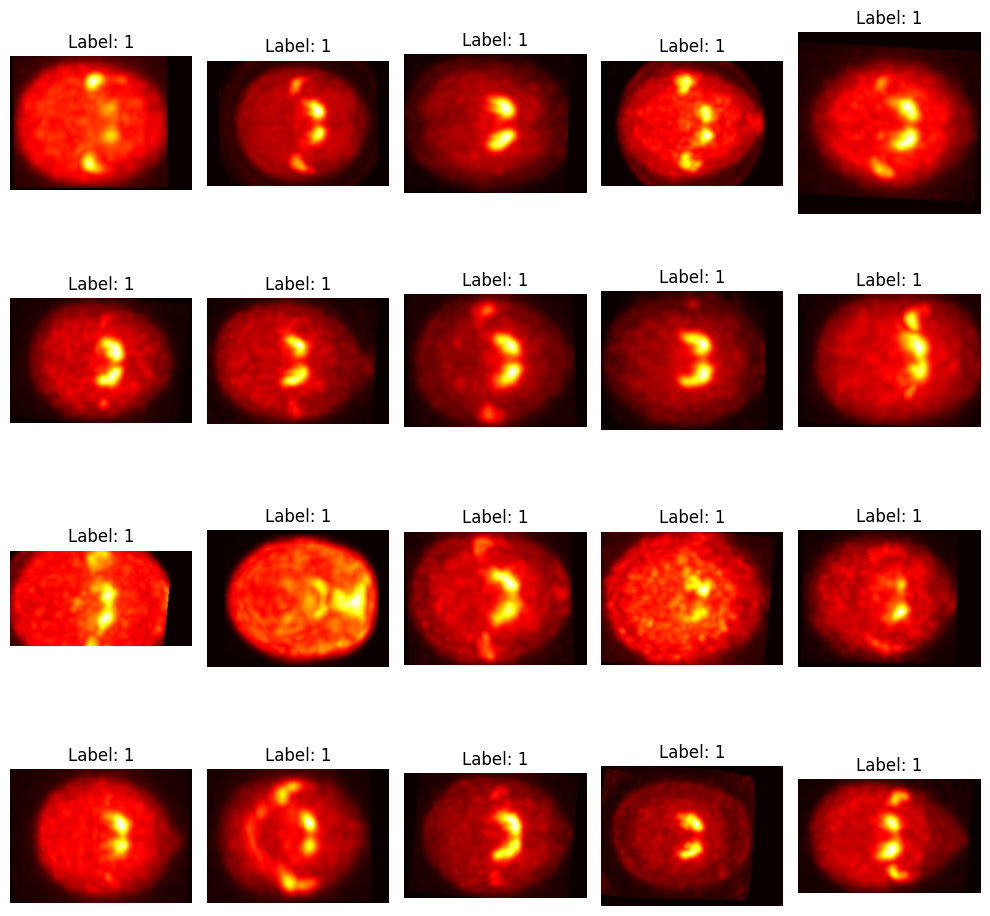

In [16]:
### Snippet que m'ha donat gemini per trobar la _slice_ que conté el striatum. 
# El faig servir més endavant també per veure si el Cropping (monai) ha anat bé.
import matplotlib.pyplot as plt
import torch
import numpy as np

print("Imatges tal qual (pre-monai)")
print("La slice escollida és la que mostra el striatum")

n_images=20
plt.figure(figsize=(10, 10))
for i in range(n_images):

    ist_path = train_df.iloc[i]['path']
    ist_label = train_df.iloc[i]['label']

    ist_img = nib.load(ist_path)
    ist_img_data = ist_img.get_fdata()

    # MIP: Take the maximum along the 'Depth' axis (axis 2 or 3 usually)
    # This collapses the 3D volume into the brightest 2D view
    mip_view = np.max(ist_img_data, axis=-1) 
    
    plt.subplot(4, 5, i + 1)
    plt.imshow(mip_view[:,:], cmap="hot")
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from monai.transforms import (
    Compose,
    LoadImaged,
    Resized,
    ScaleIntensityd,
    ScaleIntensityRangePercentilesd,
    NormalizeIntensityd,
    EnsureChannelFirstd,
    CenterSpatialCropd,
    RandGaussianSharpend,
    HistogramNormalized
)

from monai.data import Dataset as MonaiDataset

# Define the "Recipe" for your images
data_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    # resizing: 2 options, idk which is better
    # - Resize (Squashes the image to fit 96x96x96)
    #Resized(keys=["image"], spatial_size=(96, 96, 96)),
    # - CenterCrop (Trims the edges to fit 96x96x96)
    CenterSpatialCropd(keys=["image"], roi_size=(84, 84, 84)),
    #RandGaussianSharpend(keys=["image"]), # no he vist gran canvi
    #ScaleIntensityRangePercentilesd( # tallava massa
    #    keys=["image"],
    #    lower=1,   # Ignore bottom 1%
    #    upper=99,  # Ignore top 1%
    #    b_min=0.0, 
    #    b_max=1.0, 
    #    clip=True
    #)
    NormalizeIntensityd(keys=["image"]),
    #ScaleIntensityd(keys=["image"]), # també funciona ok
])

# Re-wrap your data
train_files = [{"image": p, "label": l} for p, l in zip(train_df['path'], train_df['label'])]
train_ds = MonaiDataset(data=train_files, transform=data_transforms)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)

test_files = [{"image": p, "label": l} for p, l in zip(test_df['path'], test_df['label'])]
test_ds = MonaiDataset(data=test_files, transform=data_transforms)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=True, )

A les fotos d'adalt hi ha molt soroll quan faig el Crop, q pot ser és xq estic normalitzant malament. Si hi ha un outlier o algo tota la resta es desbarata?

Preix q el `CenterSpatialCropd` de Monai fa que es vegin més grans les comes, cosa que sí que està b. 
L'altre conserva més part de la imatge original però els marges queden raros.

Imatges post monai


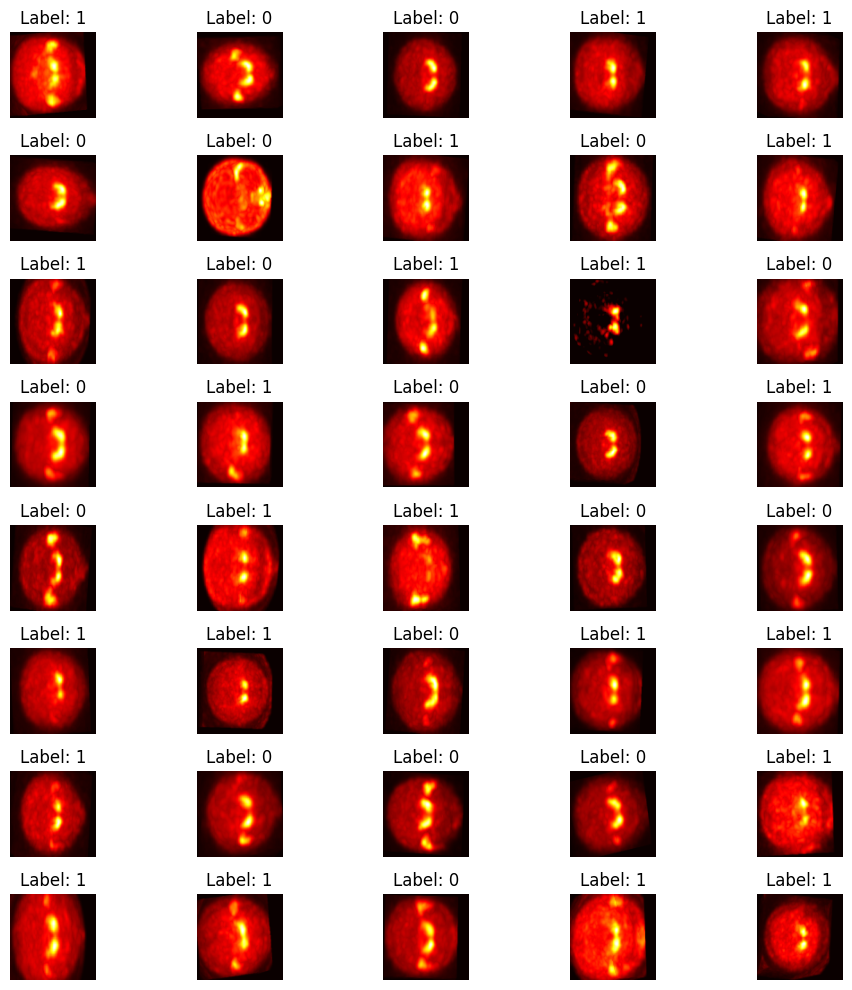

In [28]:
import matplotlib.pyplot as plt
import numpy as np

print("Imatges post monai")

n_images=40
plt.figure(figsize=(10, 10))
for i, batch in enumerate(train_loader):
    if i >= n_images: break
    
    # Get the 3D array [C, H, W, D]
    img_tensor = batch["image"][0].numpy() 
    label = batch["label"][0].item()
    
    # MIP: Take the maximum along the 'Depth' axis (axis 2 or 3 usually)
    # This collapses the 3D volume into the brightest 2D view
    mip_view = np.max(img_tensor, axis=-1) 
    
    plt.subplot(8, 5, i + 1)
    plt.imshow(mip_view[0,:,:], cmap="hot")
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()


This was to see if Monai had destroyed my images but idk what I'm looking at. Different images look very different. I'm not sure if this is desired behavior. At least they seem to all be the same size. Rotation seems to be varying too.

Now finally I've asked gemini for a function to show the slice where it can find the commas and it looks much better.
Still some small rotations but the difference between PD and HC is quite clear

# Defining the architecture

In [19]:
class ParkinsonClassifier3D_v2(nn.Module):
    def __init__(self):
        super(ParkinsonClassifier3D_v2, self).__init__()
        
        # Layer 1: Conv -> Batch Norm -> ReLU -> Pool3
        self.conv1 = nn.Conv3d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(16)
        
        # Layer 2: Conv -> Batch Norm -> ReLU -> Pool
        self.conv2 = nn.Conv3d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(32)
        
        # Layer 3: Conv -> Batch Norm -> ReLU -> Pool
        self.conv3 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm3d(64)
        
        self.pool = nn.MaxPool3d(2)
        self.gap = nn.AdaptiveAvgPool3d(1)
        
        # Fully Connected Layers with Dropout
        self.dropout = nn.Dropout3d(0.3) # Drop 30% of neurons
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # We follow the pattern: Conv -> BatchNorm -> ReLU -> Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.gap(x)
        x = x.view(-1, 64)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        # a tenir en compte: using RAW LOGITS. 
        # posar nn.BCEWithLogitsLoss() a training
        return self.fc2(x)


Ok finaly: now we trainin

# Training

> The training code is in the '.py' file to avoid running it when running the notebook.

Now the model is saved at "checkpoints/best_model.pth"

In [20]:
# Re-instantiate the model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ParkinsonClassifier3D_v2().to(device)

# Load the saved weights
model.load_state_dict(torch.load("checkpoints/best_model.pth"))

# Set to evaluation mode
model.eval()
print("Model loaded yea")

Model loaded yea


# Evaluation

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
import numpy as np
import torch

In [22]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        images = batch["image"].to(device)
        labels = batch["label"].to(device).view(-1, 1)
        
        outputs = model(images)
        
        # Get probabilities (0 to 1)
        probs = torch.sigmoid(outputs) # If you removed sigmoid from the model class
        
        # Get hard predictions (0 or 1)
        preds = (outputs > 0).float() # to float bcs pytorch is picky and floats are floats

        #print(f"image {i}\nprobs:\t{probs}\npreds:\t{preds}")
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to clean numpy arrays
all_probs = np.array(all_probs).flatten()
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/torch/nn/functional.py:1597: UserWarning: dropout3d: Received a 2-D input to dropout3d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout3d exists to provide channel-wise dropout on inputs with 3 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 4D or 5D inputs).
  warnings.warn(warn_msg)


TP: 37	PD detected
TN: 20	Healthy detected
FP: 5	Healthy missdiagnosed
FN: 0	PD missed


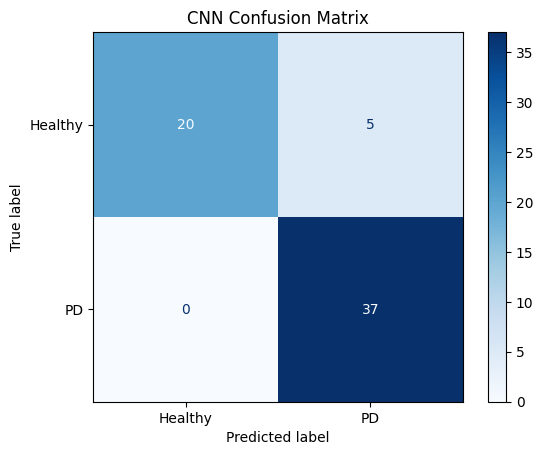

Sensitivity (Recall): 1.0000
Specificity: 0.8000

Full Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.80      0.89        25
          PD       0.88      1.00      0.94        37

    accuracy                           0.92        62
   macro avg       0.94      0.90      0.91        62
weighted avg       0.93      0.92      0.92        62



In [23]:
# Calculate the Matrix
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

print(f"TP: {tp}\tPD detected")
print(f"TN: {tn}\tHealthy detected")
print(f"FP: {fp}\tHealthy missdiagnosed")
print(f"FN: {fn}\tPD missed")

disp = ConfusionMatrixDisplay.from_predictions(
    all_labels, 
    all_preds, 
    display_labels=['Healthy', 'PD'], 
    cmap=plt.cm.Blues
)
plt.title('CNN Confusion Matrix')
plt.show()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'PD']))

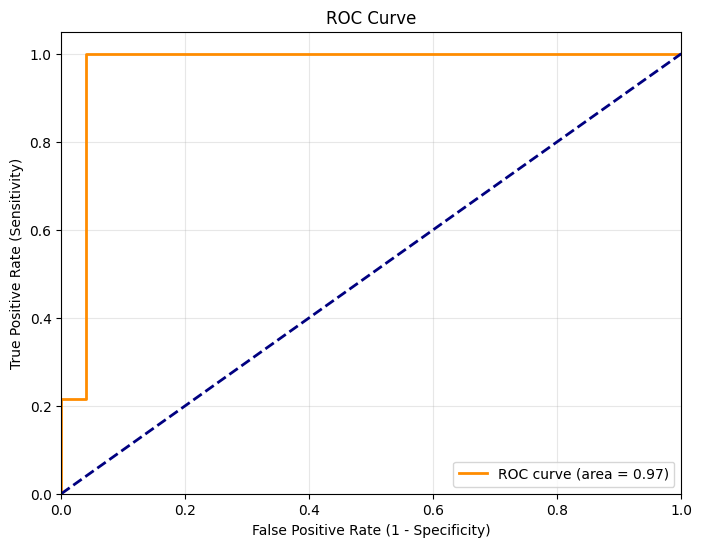

Total AUC: 0.9686


In [24]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')

# Plot the diagonal (random classifier baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Total AUC: {roc_auc:.4f}")

# results

## First go

It looks like the model only learned to say yes. This is bcs the dataset is quite skewed. Let's do sth about it and retrain.
First I'll try rebalancing, get the same ammount of PD and healthy.

## Second go

I might be missing something, it keeps getting stuck at 50%  accuracy (it always says 1)
The model did the same despite having now the same ammount of cases for each label.

I'm going to try 
- cropping the images even more so perhaps the model will focus more on the striatum?
- changing the architecture to something a bit more complex.

I'll fix this in the .py version of this so I can retrain headless on the server.

In [25]:
## Codi per exportar el model
model = ParkinsonClassifier3D_v1()
dummy_input = torch.randn(1, 1, 96, 96, 96)
torch.onnx.export(model, dummy_input, "model_architecture_v1.onnx")

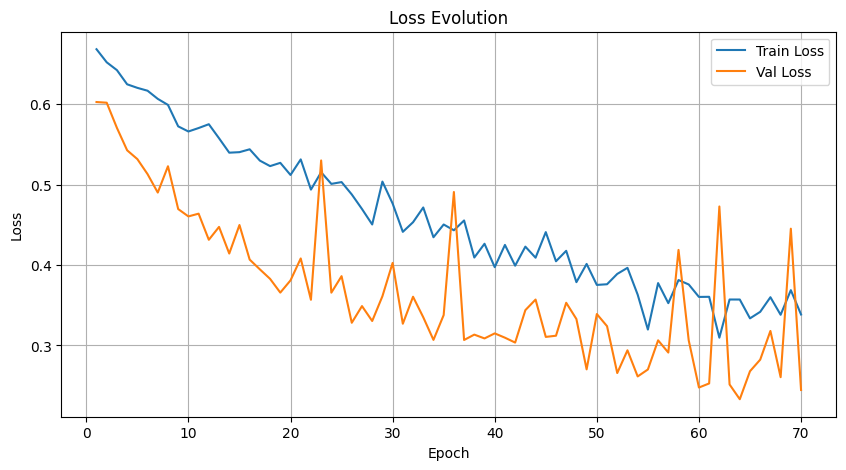

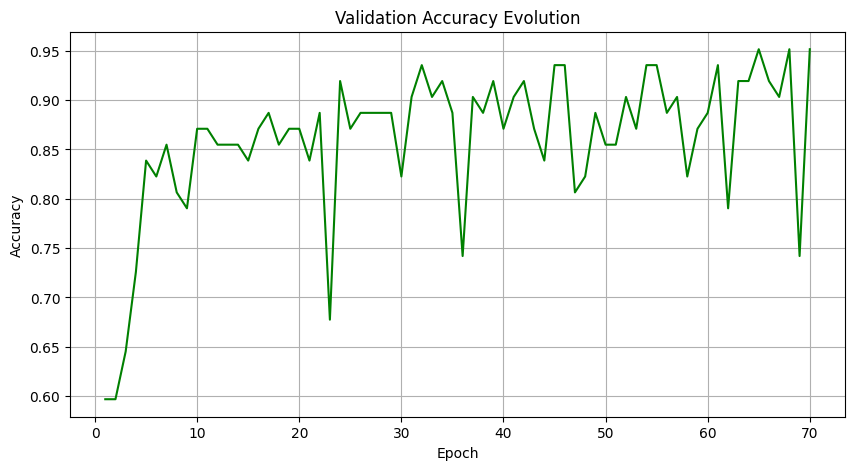

In [26]:
## visualise the code from the generated csv:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('training_log_v2.csv')

plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['val_acc'], label='Val Accuracy', color='green')
plt.title('Validation Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()